In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

from dataio.mts import get_data_single_mjd, mjd2utc, get_gts_single_mjd
from cmpmaker.runner import run
from cmpa.calc import (
    calc_nodes_ratio,
)

# Import raw data from UMK

In [2]:
mjd = 60760
gts = get_gts_single_mjd(
        datasets=["comb_hydro_698", "sr1_aom_cor", "comb_frep_dm", "rls_hydro_cavity_beat"],
        mjd=mjd, allowed_flag=1
    )
gts, cmm = gts.align_all_to_grid_zoh_and_drop_missing(start_mjd=mjd, stop_mjd=mjd+1)


Loading data from: /home/stront/svnSr/progs/clanda/npdata/comb_hydro_698/60760/comb_hydro_698_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/comb_hydro_698/60760/comb_hydro_698_60760_raw.npz
Loading data from: /home/stront/svnSr/progs/clanda/npdata/sr1_aom_cor/60760/sr1_aom_cor_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/sr1_aom_cor/60760/sr1_aom_cor_60760_raw.npz
Loading data from: /home/stront/svnSr/progs/clanda/npdata/comb_frep_dm/60760/comb_frep_dm_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/comb_frep_dm/60760/comb_frep_dm_60760_raw.npz
Loading data from: /home/stront/svnSr/progs/clanda/npdata/rls_hydro_cavity_beat/60760/rls_hydro_cavity_beat_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/rls_hydro_cavity_beat/60760/rls_hydro_cavity_beat_60760_raw.npz


# Calc f_rep from Sr88

In [3]:
fth_Sr88 = 429_228_066_418_007.0
gts.math_mts_and_number('multiply', 'comb_hydro_698', 0, 'zero')  # zero mts
gts.math_mts_and_number('multiply', 'sr1_aom_cor', 4, 'fc_aom') # atoms correction
gts.math_mts_and_number('add', 'zero', fth_Sr88, 'fth88')  # theoretical frequency of the 698 Sr clock
gts.math_mts_and_number('add', 'fth88', -121, 'fth88exp')  # theoretical frequency of the 698 Sr clock
gts.math_mts_and_mts('add', 'fth88exp', 'fc_aom', 'fcav698')  # frequency of the 698 cavity
gts.math_mts_and_number('add', 'fcav698', 84e6, 'fcomb698') # frequency of the 698 laser going to the comb

gts.math_mts_and_number('multiply', 'comb_hydro_698', -1, 'mbeat698')  # beat of the 698 laser with the comb (minus sign)
gts.math_mts_and_mts('add', 'fcomb698', 'mbeat698', 'fN698')  # frequency of the 698 laser after the comb
N698 = 1_716_959.0
gts.math_mts_and_number('add', 'fN698', -70e6, 'tmp1')  # frequency between N=1 and N698
gts.math_mts_and_number('divide', 'tmp1', N698, 'fr_88')  # f_rep


# Calc f_rep from AOS

In [4]:
# comparison with the AOS
gts.math_mts_and_number('add', 'comb_frep_dm', 980e6, 'fraostmp')
gts.math_mts_and_number('divide', 'fraostmp', 4, 'fr_aos')  # frequency measured by the AOS
gts.math_mts_and_number('multiply', 'fr_88', -1, 'mfr')  # negative fr
gts.math_mts_and_mts('add', 'mfr', 'fr_aos', 'diffr')  # diffr = fr - fr_aos
gts.math_mts_and_number('divide', 'diffr', 250e6, 'diffr_rel')  # diffr relative AOS vs Sr88
gts.append_mtserie(
        mts_name='diffr_avg',
        mts=gts.mts_dict['diffr_rel'].resample(period_s=600)
    )
gts.append_mtserie(
        mts_name='fr_aos_avg',
        mts=gts.mts_dict['fr_aos'].resample(period_s=800)
    )

# Hydro cavity

In [5]:
N1542 = 777_621.0
gts.math_mts_and_number('multiply', 'fr_88', N1542, 'tmp2') # frequency between N=1 and N1542
gts.math_mts_and_number('add', 'tmp2', 35e6+35e6, 'f1542_88')  # frequency of the 1542 cavity
gts.math_mts_and_number('multiply', 'f1542_88', -1, 'm1542_88')  # negative frequency of the 1542 cavity

ptb_freq = 194_399_987_408_400 
nc_rls = 168.5e6
gts.math_mts_and_number('add', 'rls_hydro_cavity_beat', nc_rls+ptb_freq+14e6, 'f1542_link')
gts.math_mts_and_mts('add', 'f1542_link', 'm1542_88', 'diff1542')  # frequency of the 1542 cavity from the link, minus sign because of the beatnote definition

print(f"diff 1542: {gts.mts_dict['diff1542'].mean()/1e6:.3f} MHz")

diff 1542: 0.000 MHz


/home/stront/svnSr/progs/timanda/timanda/gtserie.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


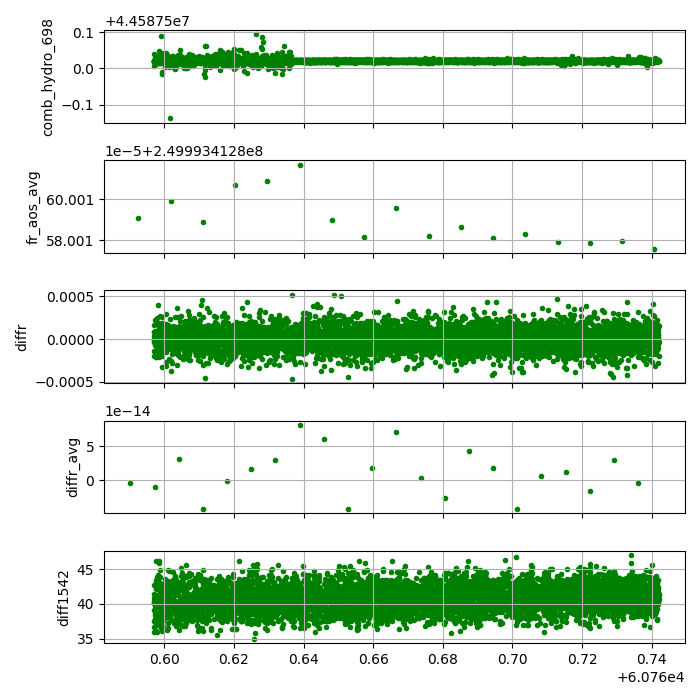

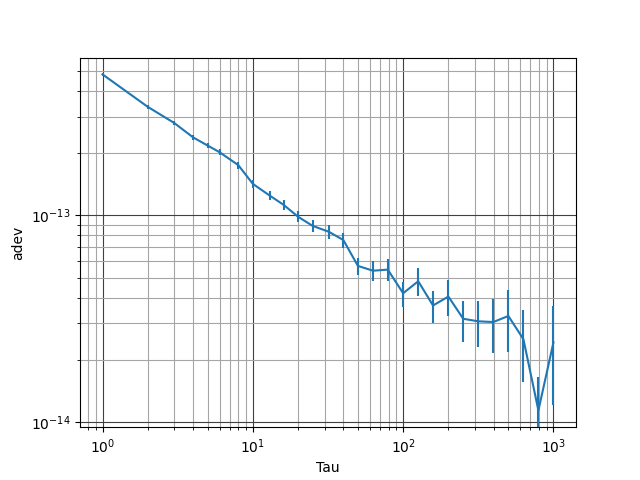

In [6]:
gts.plot(mts_names=[
    'comb_hydro_698',
    # 'fc_aom',
    # 'fr_88',
    'fr_aos_avg',
    'diffr',
    'diffr_avg',
    'diff1542',
]
)

gts.mts_dict['diffr'].plot_allan(ref_val=250e6)

# Create comparator and calc network

Loading data from: /home/stront/svnSr/progs/clanda/npdata/comb_hydro_698/60760/comb_hydro_698_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/comb_hydro_698/60760/comb_hydro_698_60760_raw.npz
Loading data from: /home/stront/svnSr/progs/clanda/npdata/sr1_aom_cor/60760/sr1_aom_cor_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/sr1_aom_cor/60760/sr1_aom_cor_60760_raw.npz


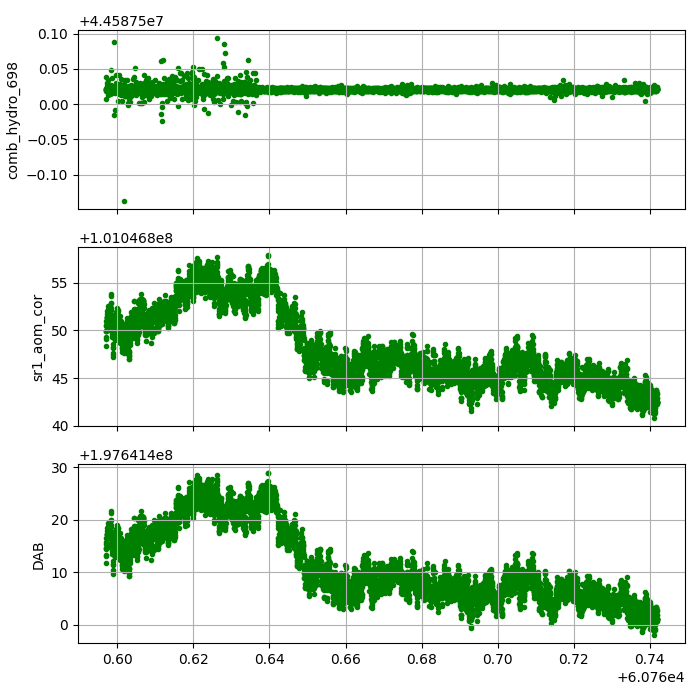

In [7]:
run(
    script_path="comparators/UMK_LO-UMK_Sr1",
    from_mjd=mjd,
    to_mjd=mjd + 0.1,
    plot=True,
    create_cmp_file=True,
)


Loading data from: /home/stront/svnSr/progs/clanda/npdata/rls_hydro_cavity_beat/60760/rls_hydro_cavity_beat_60760_raw.npz
/home/stront/svnSr/progs/clanda/npdata/rls_hydro_cavity_beat/60760/rls_hydro_cavity_beat_60760_raw.npz
[np.float64(60760.00000031246)]


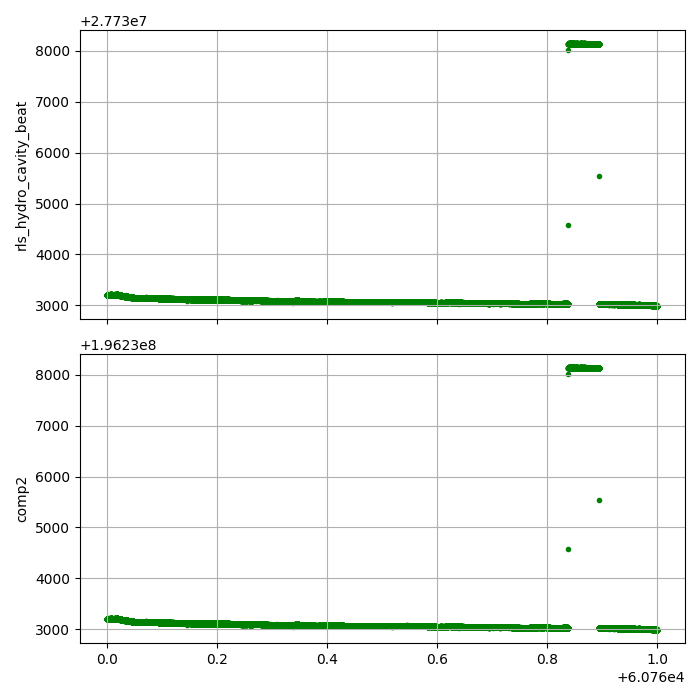

In [8]:
run(
    script_path="comparators/PTB_NIRP-PTB_RLS",
    from_mjd=mjd,
    to_mjd=mjd + 0.1,
    plot=True,
    create_cmp_file=True,
)

run(
    script_path="comparators/PTB_RLS-UMK_RLS",
    from_mjd=mjd,
    to_mjd=mjd + 0.1,
    plot=True,
    create_cmp_file=True,
)

run(
    script_path="comparators/UMK_LO-UMK_RLS",
    from_mjd=mjd,
    to_mjd=mjd + 0.1,
    plot=True,
    create_cmp_file=True,
)


[PATH] edges:
PTB_Yb_CombKnoten <--> PTB_Si   (1): PTB_Si-PTB_Yb_CombKnoten
PTB_Si <--> PTB_NIRP   (1): PTB_Si-PTB_NIRP
PTB_NIRP <--> PTB_RLS   (1): PTB_NIRP-PTB_RLS
PTB_RLS <--> UMK_RLS   (1): PTB_RLS-UMK_RLS
UMK_RLS <--> UMK_LO   (1): UMK_LO-UMK_RLS
UMK_LO <--> UMK_Sr1   (1): UMK_LO-UMK_Sr1

[LOAD] Creating GTserie and loading MTSeries:
 - PTB_Si-PTB_Yb_CombKnoten
 - PTB_Si-PTB_NIRP
 - PTB_NIRP-PTB_RLS
 - PTB_RLS-UMK_RLS
 - UMK_LO-UMK_RLS
 - UMK_LO-UMK_Sr1


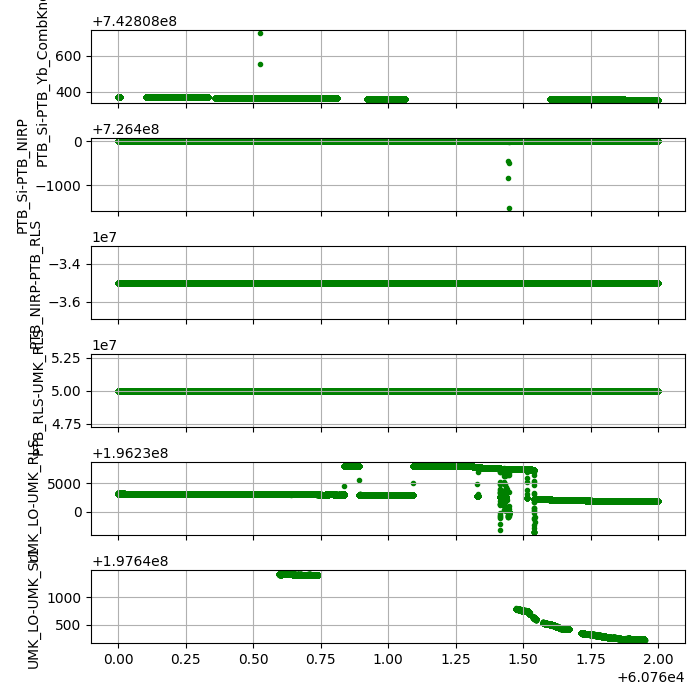



[MODEL] nu0_ref = nu0(PTB_Yb_CombKnoten) = 6.421215e+14 Hz
[STEP] 
	PTB_Yb_CombKnoten->PTB_Si: 'PTB_Si-PTB_Yb_CombKnoten' (forward), 
	rho0_yaml=3.0274644436772513e-01, rho0_step(path)=3.0274644436772513e-01, 
	prod_prev(after)=3.0274644436772513e-01, scale=5.144033e-15
[STEP] 
	PTB_Si->PTB_NIRP: 'PTB_Si-PTB_NIRP' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=3.0274644436772513e-01, scale=-5.144033e-15
[STEP] 
	PTB_NIRP->PTB_RLS: 'PTB_NIRP-PTB_RLS' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=3.0274644436772513e-01, scale=-5.144033e-15
[STEP] 
	PTB_RLS->UMK_RLS: 'PTB_RLS-UMK_RLS' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=3.0274644436772513e-01, scale=-5.144033e-15
[STEP] 
	UMK_RLS->UMK_LO: 'UMK_LO-UMK_RLS' (forward), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_pre

In [9]:
mts = calc_nodes_ratio(
        fmjd=mjd,
        tmjd=mjd+1,
        start_node='PTB_Yb_CombKnoten',
        goal_node='UMK_Sr1',
    )


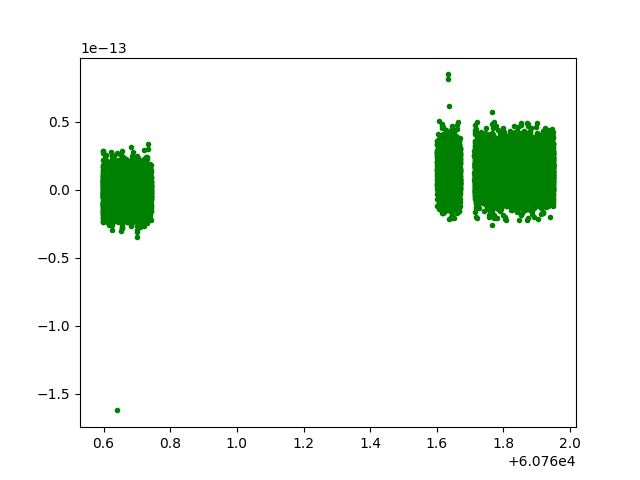

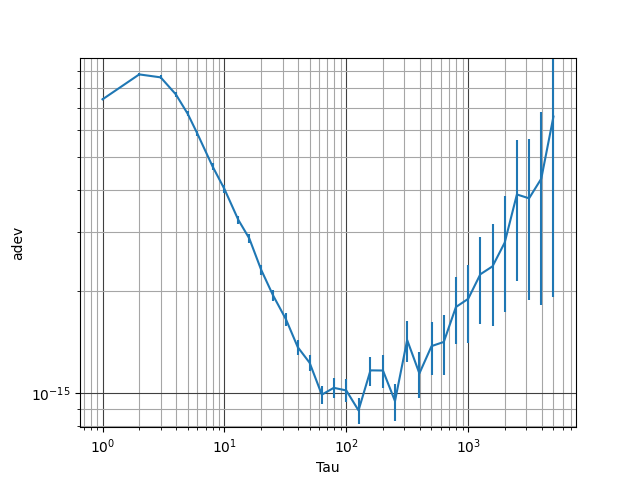

In [10]:
rmts = mts.resample(period_s=1200)
mts.plot()
mts.plot_allan()
# rmts.plot()g
